# Employee Satisfaction Analysis

## INTRODUCTION

This file provides an analysis of employees based on ordinal data (subjective employee ratings), such as work–life balance, job satisfaction, relationship satisfaction, and more.

In [394]:
# CHANGE USER_PATH

from pathlib import Path


USER_PATH = Path(r"C:\Users\Mateusz\Desktop\ZBIORCZE\TECH\ANALIZA DANYCH\Python\Projekty MB") 


df_path = USER_PATH / "Python Analysis of Employee Attrition and Performance" / "dataframe.csv"

In [395]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df=pd.read_csv(df_path)

### Employee Work-Life Balance 

In [396]:
balance = df["WorkLifeBalance"].value_counts()

all_values = len(df)

balance = balance.reset_index()

In [397]:
dict_rate = {
    1: '1.Bad',
    2: '2.Good',
    3: '3.Better',
    4: '4.Best'
}

balance["Rate"] = balance["WorkLifeBalance"].map(dict_rate)

balance.drop(columns="WorkLifeBalance", axis=1, inplace=True)

In [398]:
balance["count"] = balance["count"] / all_values * 100

balance["count"] = balance["count"].round(2)

balance.sort_values(by= "Rate", inplace=True)

balance["Rate"] = balance["Rate"].str[2:]

balance.set_index(keys="Rate", inplace=True)

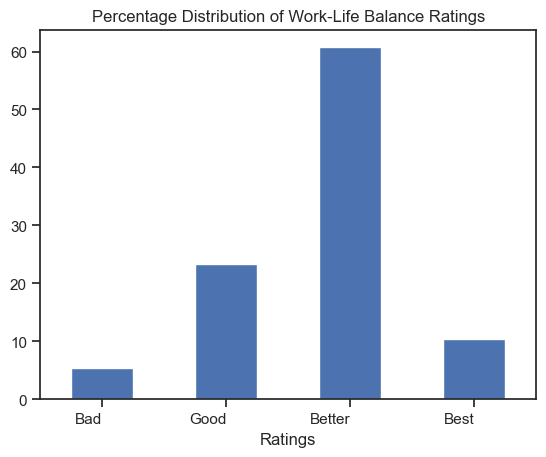

In [399]:
sns.set_theme(style='ticks')

balance.plot(kind="bar")

plt.title("Percentage Distribution of Work-Life Balance Ratings")
plt.ylabel("")
plt.xlabel("Ratings")

plt.legend().remove()

plt.xticks(rotation = 0, ha = "right")


plt.show()

### Employee Work-Life Balance (Depending on Overtime Work)

In [400]:
balance_ovt = df[df["OverTime"] == True].copy()

balance_no_ovt = df[df["OverTime"] == False].copy()

balance_ovt = balance_ovt["WorkLifeBalance"].value_counts()

balance_no_ovt = balance_no_ovt["WorkLifeBalance"].value_counts()

balance_ovt = balance_ovt.reset_index()

balance_no_ovt = balance_no_ovt.reset_index()

In [401]:
# this is the same code as above

dict_rate = {
    1: '1.Bad',
    2: '2.Good',
    3: '3.Better',
    4: '4.Best'
}

balance_ovt["Rate"] = balance_ovt["WorkLifeBalance"].map(dict_rate)

balance_ovt.drop(columns="WorkLifeBalance", axis=1, inplace=True)

balance_ovt.sort_values(by= "Rate", inplace=True)

balance_ovt["Rate"] = balance_ovt["Rate"].str[2:]

balance_ovt.set_index(keys="Rate", inplace=True)

In [402]:
# this is the same code as above

dict_rate = {
    1: '1.Bad',
    2: '2.Good',
    3: '3.Better',
    4: '4.Best'
}

balance_no_ovt["Rate"] = balance_no_ovt["WorkLifeBalance"].map(dict_rate)

balance_no_ovt.drop(columns="WorkLifeBalance", axis=1, inplace=True)

balance_no_ovt.sort_values(by= "Rate", inplace=True)

balance_no_ovt["Rate"] = balance_no_ovt["Rate"].str[2:]

balance_no_ovt.set_index(keys="Rate", inplace=True)

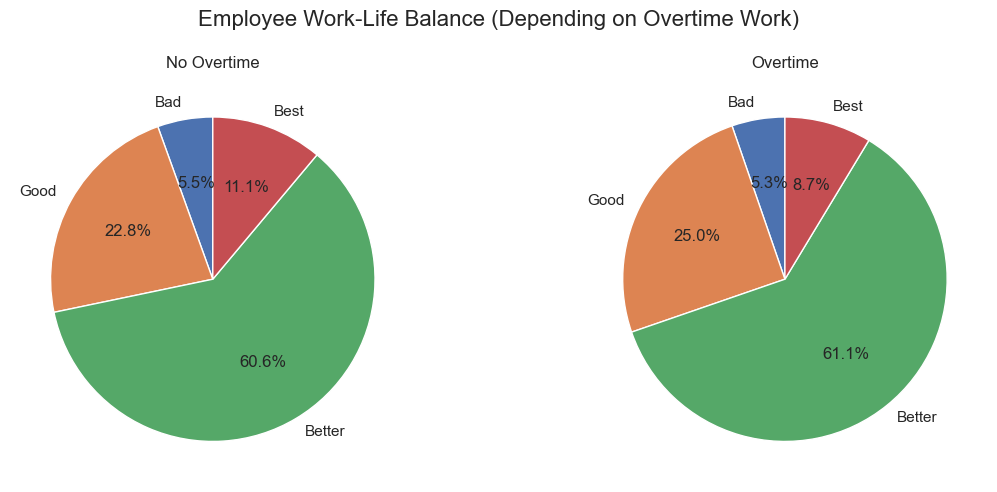

In [403]:
fig, ax = plt.subplots(1, 2)
fig.set_size_inches((12, 5))

plt.subplot(1, 2, 1)
plt.pie(
    balance_no_ovt["count"],  # albo inna kolumna
    labels=["Bad", "Good", "Better", "Best"],
    autopct='%1.1f%%',
    startangle=90
)
plt.title("No Overtime")

plt.subplot(1, 2, 2)
plt.pie(
    balance_ovt["count"],  # albo inna kolumna
    labels=["Bad", "Good", "Better", "Best"],
    autopct='%1.1f%%',
    startangle=90
)
plt.title("Overtime")

plt.suptitle("Employee Work-Life Balance (Depending on Overtime Work)", fontsize=16)
plt.tight_layout()
plt.show()

### Education and Rate Comparsion 

In [405]:
df["JobSatisfaction"].unique()

array([4, 2, 3, 1])

In [406]:
rel = df[["YearsSinceLastPromotion", "JobSatisfaction"]]

rel.value_counts()


YearsSinceLastPromotion  JobSatisfaction
0                        3                  180
                         4                  175
                         1                  117
1                        4                  111
0                        2                  109
                                           ... 
12                       1                    2
14                       2                    2
9                        2                    1
13                       2                    1
14                       4                    1
Name: count, Length: 63, dtype: int64

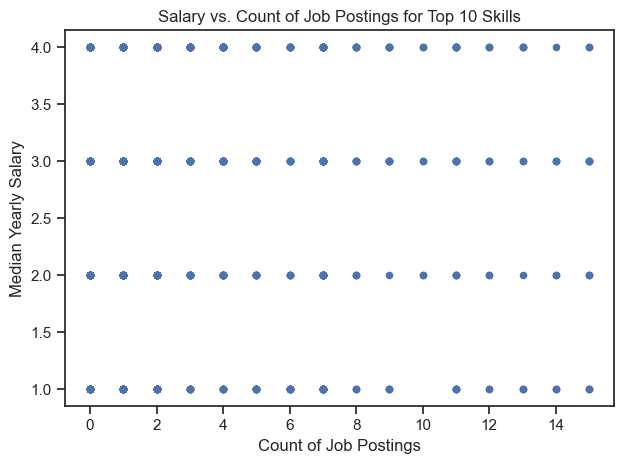

In [407]:
rel.plot(kind='scatter', x="YearsSinceLastPromotion", y="JobSatisfaction")
plt.xlabel('Count of Job Postings')
plt.ylabel('Median Yearly Salary')
plt.title('Salary vs. Count of Job Postings for Top 10 Skills')
plt.tight_layout()
plt.show()

In [408]:
# albo total working years i years at company

# lata w firmie i enivornment satisfaction

In [409]:
df.columns

Index(['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department',
       'DistanceFromHome', 'Education', 'EducationField',
       'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement',
       'JobLevel', 'JobRole', 'JobSatisfaction', 'MaritalStatus',
       'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'OverTime',
       'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction',
       'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear',
       'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole',
       'YearsSinceLastPromotion', 'YearsWithCurrManager'],
      dtype='object')

In [410]:
df.head(5)

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,True,Travel Rarely,1102,Sales,1,2,Life Sciences,2,Female,...,3,1,0,8,0,1,6,4,0,5
1,49,False,Travel Frequently,279,Research & Development,8,1,Life Sciences,3,Male,...,4,4,1,10,3,3,10,7,1,7
2,37,True,Travel Rarely,1373,Research & Development,2,2,Other,4,Male,...,3,2,0,7,3,3,0,0,0,0
3,33,False,Travel Frequently,1392,Research & Development,3,4,Life Sciences,4,Female,...,3,3,0,8,3,3,8,7,3,0
4,27,False,Travel Rarely,591,Research & Development,2,1,Medical,1,Male,...,3,4,1,6,3,3,2,2,2,2
